# N10 — Memória em LangGraph

* Professor: Julio Cesar dos Reis <a href="mailto:dosreis@unicamp.br">(dosreis@unicamp.br)</a>
* Monitor: Renan dos Santos Morais <a href="mailto:r299211@dac.unicamp.br">(r299211@dac.unicamp.br)</a>


## 0.1 Pré-requisitos

Para acompanhar este notebook, é esperado que você já tenha:

- concluído ou entendido as aulas anteriores de LangGraph (grafos, LLMs, ferramentas);
- noções de `StateGraph`, `TypedDict`, reducers e `add_messages`;
- noções básicas de tool calling (Notebook 4);
- familiaridade básica com `sqlite3` (não é necessário ser especialista, só saber que é um banco de dados em um único arquivo).


## 0.2 Objetivos

Ao final deste notebook, você deverá saber:

1. Diferenciar `RunnableConfig` de `Runtime`/`Context` e saber quando usar cada um.
2. Explicar a diferença entre memória de **curto prazo** e memória de **longo prazo** em LangGraph.
3. Usar um `checkpointer` para persistir o estado de uma conversa entre chamadas (`SqliteSaver`).
4. Usar um `store` para persistir informações entre *threads* diferentes (`SqliteStore`).
5. Implementar dois padrões de memória de longo prazo: memória tipo **documento** (perfil do aluno) e memória **episódica** (histórico de conversas).
6. Combinar checkpointer e store no mesmo agente.


## 0.3 Mapa do notebook

Neste notebook, vamos construir progressivamente:

1. A premissa: por que o estado do grafo, sozinho, não é memória.
2. `RunnableConfig`: passando dados de fora para dentro do grafo.
3. `Runtime` e `Context`: a evolução do `RunnableConfig`.
4. Memória de curto prazo com `checkpointer` (`SqliteSaver`).
5. Memória de longo prazo com `store` (`SqliteStore`): documento e memória episódica.
6. Um agente único combinando as duas camadas de memória.


## 0.4 Contexto usado nos exemplos

Para manter a continuidade com os notebooks anteriores, os exemplos deste notebook usam o mesmo cenário:

- existe um **curso de LangGraph** organizado em módulos (`A4`, `A5`, `A6`);
- alunos como **Renan**, **Ana** e **Julio** interagem com um assistente/tutor do curso;
- o assistente precisa, ao longo desta aula, **lembrar** de quem é o aluno, do que já foi conversado, e de preferências salvas entre sessões diferentes.

---

## 0.5 Preparação do ambiente

Este notebook assume que você já tem LangChain, LangGraph e um provedor de LLM configurados.

Adicionalmente, vamos usar dois pacotes novos, específicos para persistência em SQLite:

- `langgraph-checkpoint-sqlite`: fornece `SqliteSaver` (checkpointer) e `SqliteStore` (store).


In [7]:
# Descomente se estiver em um ambiente sem as dependências instaladas.
%pip install -U langgraph langchain langchain-ollama langgraph-checkpoint-sqlite pydantic


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Agora importamos os elementos que serão usados ao longo da aula.

In [18]:
from dataclasses import dataclass
from datetime import datetime
import os
import sqlite3
import uuid

from typing import Annotated, TypedDict

from langchain.chat_models import init_chat_model
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.runtime import Runtime

from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.store.sqlite import SqliteStore
from langgraph.store.base import BaseStore


Importamos elementos de três frentes diferentes:

- **LangChain**: `init_chat_model`, tipos de mensagem (`HumanMessage`, `SystemMessage`, `BaseMessage`).
- **LangGraph — núcleo**: `StateGraph`, `START`, `END`, `add_messages`, `Runtime`.
- **LangGraph — persistência**: `SqliteSaver` (checkpointer, memória de curto prazo) e `SqliteStore`/`BaseStore` (store, memória de longo prazo).


Vamos criar funções auxiliares para exibir os grafos compilados e imprimir mensagens de forma compacta.

In [19]:
from langgraph.graph.state import CompiledStateGraph
from IPython.display import Image, display, Markdown


def display_graph(graph: CompiledStateGraph) -> None:
    display(Image(graph.get_graph().draw_mermaid_png()))


def print_messages(messages: list[BaseMessage]) -> None:
    """Imprime uma conversa de maneira compacta."""
    for message in messages:
        tipo = type(message).__name__
        print(f"[{tipo}] {message.content}")


def print_last_message(result: dict) -> None:
    """Imprime apenas a última mensagem de um resultado de grafo."""
    display(Markdown(result["messages"][-1].content))


Agora inicializamos o modelo.

O restante do notebook usa a variável `llm`. Troque o provedor conforme o que você configurou (Ollama, Gemini ou OpenAI) — o mecanismo de memória apresentada aqui não depende do provedor escolhido.

In [20]:
# Reaproveite aqui a mesma configuração de LLM usada no Notebook 3.
# Exemplo com Ollama (modelo local, sem chave):
# llm = init_chat_model("ollama:llama3.2:3b", temperature=0)

# Se preferir um provedor via API (Gemini, OpenAI etc.), siga o mesmo processo
# apresentado na seção 0.5 do Notebook 3 e apenas troque a linha acima.

from dotenv import load_dotenv

load_dotenv()
print("Chave OPENAI_API_KEY configurada com sucesso." if "OPENAI_API_KEY" in os.environ else "Chave não encontrada.")

llm = init_chat_model("openai:gpt-4o-mini", temperature=0)


Chave OPENAI_API_KEY configurada com sucesso.


---

# 1. Premissa: o estado do grafo não é memória

Até então, construímos chatbots cujo estado guardava `messages`. 

Isso pode dar a impressão de que o grafo "lembra" da conversa. Mas essa memória só existe **durante uma única chamada** a `invoke`/`stream`.

Vamos comprovar isso com o tutor do curso.

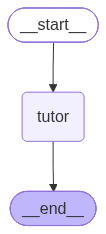

In [21]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


def tutor_sem_memoria(state: ChatState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}


builder = StateGraph(ChatState)
builder.add_node("tutor", tutor_sem_memoria)
builder.add_edge(START, "tutor")
builder.add_edge("tutor", END)

grafo_sem_memoria = builder.compile()
display_graph(grafo_sem_memoria)


Vamos simular duas mensagens que deveriam fazer parte da mesma conversa.

In [22]:
resultado_1 = grafo_sem_memoria.invoke(
    {"messages": [HumanMessage(content="Oi, meu nome é Renan e estou no módulo A6.")]}
)
print_last_message(resultado_1)


Oi, Renan! Como posso te ajudar hoje no módulo A6? Se tiver alguma dúvida ou precisar de informações, é só me avisar!

In [23]:
resultado_2 = grafo_sem_memoria.invoke(
    {"messages": [HumanMessage(content="Qual é o meu nome e em qual módulo eu estou?")]}
)
print_last_message(resultado_2)


Desculpe, mas não tenho acesso a informações pessoais sobre você, como seu nome ou o módulo em que você está. Se precisar de ajuda com algo específico, sinta-se à vontade para perguntar!

## 1.1 O que aconteceu?

Cada chamada a `invoke` começou com um estado novo. A segunda chamada não tem acesso às mensagens da primeira, porque nada foi persistido entre uma chamada e outra.

Isso não é um bug: é o comportamento esperado de um grafo sem persistência. Para que o assistente "lembre", precisamos de dois ingredientes que vamos construir nesta aula:

1. um jeito de **identificar** quem está conversando e em que contexto (`RunnableConfig` / `Runtime`);
2. um jeito de **persistir** informação entre chamadas (`checkpointer` e `store`).


---

# 2. `RunnableConfig`: passando dados de fora para dentro do grafo

Até agora, tudo o que um nó conhece vem do `state`. Mas nem toda informação de uma execução deveria virar campo do estado.

Exemplo: **quem é o aluno** e **qual thread de conversa** está sendo executada são metadados da execução, não "dados da conversa" que precisam ser acumulados junto com as mensagens.

Para esse tipo de informação, o LangGraph oferece o `RunnableConfig`: um dicionário passado como segundo argumento em `invoke`/`stream`, com uma chave especial chamada `configurable`.

```text
config = {
    "configurable": {
        "thread_id": "renan-01",
        "aluno": "Renan",
    }
}
```

Qualquer nó pode declarar um parâmetro `config: RunnableConfig` e ler esses valores.

## 2.1 Um nó que lê o `RunnableConfig`

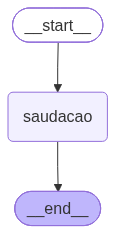

In [25]:
from langchain_core.runnables import RunnableConfig


class SaudacaoState(TypedDict):
    mensagem: str


def saudacao_personalizada(state: SaudacaoState, config: RunnableConfig):
    aluno = config["configurable"].get("aluno", "aluno(a)")
    return {"mensagem": f"Olá, {aluno}! Pronto para continuar o curso de LangGraph?"}


builder = StateGraph(SaudacaoState)
builder.add_node("saudacao", saudacao_personalizada)
builder.add_edge(START, "saudacao")
builder.add_edge("saudacao", END)

grafo_saudacao = builder.compile()
display_graph(grafo_saudacao)


Executamos o mesmo grafo com dois alunos diferentes, apenas trocando o `config`.

In [26]:
for aluno in ["Renan", "Ana"]:
    config = {"configurable": {"aluno": aluno}}
    resultado = grafo_saudacao.invoke({"mensagem": ""}, config)
    print(resultado["mensagem"])


Olá, Renan! Pronto para continuar o curso de LangGraph?
Olá, Ana! Pronto para continuar o curso de LangGraph?


## 2.2 Por que não colocar `aluno` no estado?

Poderíamos ter feito isso. A diferença é de intenção:

- **estado**: dado que faz parte do fluxo de dados do grafo, é lido e escrito por nós, muda de um passo para o outro.
- **config**: metadado da execução — normalmente definido uma vez, no início, e não muda durante o grafo.

`thread_id` é o exemplo mais importante de valor de `config`: ele identifica **qual conversa** está sendo executada, e será essencial já na próxima seção, quando ligarmos um checkpointer.


---

# 3. `Runtime` e `Context`: a evolução do `RunnableConfig`

Usar `config["configurable"]["aluno"]` funciona, mas tem dois problemas:

- é uma string "solta" — nada garante que a chave `"aluno"` existe ou que é do tipo certo;
- fica cada vez mais aninhado conforme a aplicação cresce.

LangGraph mais recente resolve isso com **`context_schema`** e **`Runtime`**: um objeto tipado, análogo ao `state`, mas para dados imutáveis da execução (não acumulados, não retornados pelos nós).

## 3.1 Definindo um `Context`

Declaramos o formato do contexto com uma `dataclass`, do mesmo jeito que declaramos o estado com `TypedDict`.

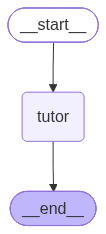

In [28]:
@dataclass
class CursoContext:
    aluno: str
    idioma: str = "pt"


def tutor_com_contexto(state: SaudacaoState, runtime: Runtime[CursoContext]):
    aluno = runtime.context.aluno
    if runtime.context.idioma == "en":
        mensagem = f"Hello, {aluno}! Ready to keep going with LangGraph?"
    else:
        mensagem = f"Olá, {aluno}! Pronto para continuar o curso de LangGraph?"
    return {"mensagem": mensagem}


builder = StateGraph(SaudacaoState, context_schema=CursoContext)
builder.add_node("tutor", tutor_com_contexto)
builder.add_edge(START, "tutor")
builder.add_edge("tutor", END)

grafo_com_contexto = builder.compile()
display_graph(grafo_com_contexto)


O contexto é passado pelo parâmetro `context` do `invoke` — não fica dentro de `config`.

In [29]:
resultado_pt = grafo_com_contexto.invoke(
    {"mensagem": ""}, context=CursoContext(aluno="Renan", idioma="pt")
)
print(resultado_pt["mensagem"])

resultado_en = grafo_com_contexto.invoke(
    {"mensagem": ""}, context=CursoContext(aluno="Ana", idioma="en")
)
print(resultado_en["mensagem"])


Olá, Renan! Pronto para continuar o curso de LangGraph?
Hello, Ana! Ready to keep going with LangGraph?


## 3.2 Comparando as duas formas

| | `RunnableConfig` | `Runtime` / `Context` |
|---|---|---|
| Onde declara o formato | não declara (dict solto) | `context_schema` na `StateGraph` |
| Onde acessa no nó | `config["configurable"]["chave"]` | `runtime.context.chave` |
| Onde passa no invoke | `config={"configurable": {...}}` | `context=MeuContext(...)` |
| Checagem de tipos | não | sim (é uma `dataclass`/`TypedDict`) |
| Continua existindo? | sim, principalmente para `thread_id` e integrações mais antigas | é a forma recomendada para dados novos |

Importante: **`Runtime` não substitui `RunnableConfig` por completo**. Coisas como `thread_id` (usado pelo checkpointer) continuam vivendo em `config["configurable"]`. Se um nó precisar dos dois ao mesmo tempo, basta declarar ambos os parâmetros:

```python
def meu_no(state: EstadoQualquer, config: RunnableConfig, runtime: Runtime[MeuContext]):
    ...
```

Nas próximas seções, vamos usar principalmente `config["configurable"]["thread_id"]` (para checkpointer) e `runtime.store` (para o store, que veremos na seção 5).


---

# 4. Memória de curto prazo: `checkpointer`

Um **checkpointer** salva uma cópia (*checkpoint*) do estado do grafo a cada *super-step* — ou seja, depois de cada rodada de nós executados. Cada checkpoint fica associado a um `thread_id`.

```text
thread_id → [checkpoint 1, checkpoint 2, checkpoint 3, ...]
```

Quando você chama `invoke` de novo com o **mesmo** `thread_id`, o LangGraph carrega o último checkpoint daquela thread e continua a partir dali. É assim que uma conversa "lembra" do que já foi dito — sem que você precise reenviar o histórico manualmente.

Isso é memória de **curto prazo**: escopada a uma thread (uma conversa). Threads diferentes não compartilham checkpoints entre si.

## 4.1 Criando um `SqliteSaver`

Vamos usar a forma mais trivial possível: um arquivo SQLite local, aberto com `sqlite3.connect`.

In [30]:
conexao_checkpoint = sqlite3.connect("memoria_curto_prazo.db", check_same_thread=False)
checkpointer = SqliteSaver(conexao_checkpoint)


## 4.2 Compilando o grafo com o checkpointer

Vamos reaproveitar o tutor da seção 1, agora compilado **com** `checkpointer=checkpointer`.

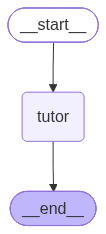

In [31]:
def tutor_com_memoria(state: ChatState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}


builder = StateGraph(ChatState)
builder.add_node("tutor", tutor_com_memoria)
builder.add_edge(START, "tutor")
builder.add_edge("tutor", END)

grafo_com_checkpoint = builder.compile(checkpointer=checkpointer)
display_graph(grafo_com_checkpoint)


## 4.3 Conversando com `thread_id`

Agora o `config` passa a ter um papel prático: `thread_id` decide qual conversa está sendo continuada.

In [32]:
config_renan = {"configurable": {"thread_id": "renan-01"}}

resultado_1 = grafo_com_checkpoint.invoke(
    {"messages": [HumanMessage(content="Oi, meu nome é Renan e estou no módulo A6.")]},
    config_renan,
)
print_last_message(resultado_1)


Oi, Renan! Como posso te ajudar hoje no módulo A6? Se tiver alguma dúvida ou precisar de informações, é só me avisar!

In [33]:
resultado_2 = grafo_com_checkpoint.invoke(
    {"messages": [HumanMessage(content="Qual é o meu nome e em qual módulo eu estou?")]},
    config_renan,
)
print_last_message(resultado_2)


Seu nome é Renan e você está no módulo A6. Se precisar de ajuda com algo específico, é só me avisar!

Dessa vez o modelo consegue responder, porque as duas chamadas usaram o mesmo `thread_id`. Vamos confirmar que uma thread **diferente** não tem acesso a essa conversa.

In [34]:
config_ana = {"configurable": {"thread_id": "ana-01"}}

resultado_ana = grafo_com_checkpoint.invoke(
    {"messages": [HumanMessage(content="Qual é o meu nome?")]},
    config_ana,
)
print_last_message(resultado_ana)


Desculpe, mas não tenho acesso a informações pessoais, incluindo o seu nome. Como posso ajudar você hoje?

## 4.4 Inspecionando o que foi salvo

O método `get_state` mostra o snapshot mais recente de uma thread. 

In [35]:
snapshot = grafo_com_checkpoint.get_state(config_renan)
print("Próximo nó a executar:", snapshot.next)
print("Quantidade de mensagens salvas:", len(snapshot.values["messages"]))
for mensagem in snapshot.values["messages"]:
    print(f"  [{type(mensagem).__name__}] {mensagem.content}")


Próximo nó a executar: ()
Quantidade de mensagens salvas: 4
  [HumanMessage] Oi, meu nome é Renan e estou no módulo A6.
  [AIMessage] Oi, Renan! Como posso te ajudar hoje no módulo A6? Se tiver alguma dúvida ou precisar de informações, é só me avisar!
  [HumanMessage] Qual é o meu nome e em qual módulo eu estou?
  [AIMessage] Seu nome é Renan e você está no módulo A6. Se precisar de ajuda com algo específico, é só me avisar!


O método `get_state_history` apresenta todos os checkpoints salvos, do mais recente para o mais antigo.

In [36]:
for i, checkpoint in enumerate(grafo_com_checkpoint.get_state_history(config_renan)):
    print(f"Checkpoint {i}: {len(checkpoint.values.get('messages', []))} mensagem(ns)")


Checkpoint 0: 4 mensagem(ns)
Checkpoint 1: 3 mensagem(ns)
Checkpoint 2: 2 mensagem(ns)
Checkpoint 3: 2 mensagem(ns)
Checkpoint 4: 1 mensagem(ns)
Checkpoint 5: 0 mensagem(ns)


## 4.5 Espiando o banco por dentro

O checkpointer é, na prática, só uma tabela SQLite. Vamos confirmar isso consultando o arquivo diretamente, sem passar pelo LangGraph.

In [37]:
cursor = conexao_checkpoint.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print("Tabelas no banco:", cursor.fetchall())

cursor.execute("SELECT thread_id, checkpoint_id FROM checkpoints ORDER BY checkpoint_id DESC LIMIT 5;")
print("\nÚltimos checkpoints salvos:")
for linha in cursor.fetchall():
    print(" ", linha)


Tabelas no banco: [('checkpoints',), ('writes',)]

Últimos checkpoints salvos:
  ('ana-01', '1f1919db-81f5-64f5-8001-c15cd753c3bf')
  ('ana-01', '1f1919db-75a6-68ee-8000-8de82903455e')
  ('ana-01', '1f1919db-759f-6740-bfff-4ab51079939e')
  ('renan-01', '1f1919da-4db4-6b9e-8004-c25c71d9bead')
  ('renan-01', '1f1919da-3b13-6559-8003-a4db8487f2ba')


## Discussão

Alguns pontos importantes sobre checkpointer:

- Ele salva o **estado inteiro**, não só o campo `messages`. 
- Se o estado tivesse outros campos, todos seriam persistidos a cada passo.
- A chave que separa uma conversa da outra é o `thread_id` — nada mais.
- `SqliteSaver` é ótimo para desenvolvimento local e prototipagem. Em produção, o equivalente é o `PostgresSaver`, com a mesma interface.
- Checkpointer resolve **memória de curto prazo**: o que aconteceu *dentro* de uma conversa. Ele não ajuda a lembrar de um aluno em uma conversa **nova** — para isso, precisamos do `store`, na próxima seção.


---

# 5. Memória de longo prazo: `store`

## 5.1 Checkpointer vs. Store

| | Checkpointer | Store |
|---|---|---|
| Escopo | uma `thread_id` | qualquer namespace (ex.: por aluno) |
| O que guarda | o estado inteiro, a cada passo | valores que você escolhe salvar explicitamente |
| Atravessa conversas novas? | não | sim |
| Uso típico | histórico de uma conversa | perfil do usuário, preferências, memórias episódicas |

Ou seja: se Renan começar uma conversa **nova** amanhã (uma `thread_id` diferente), o checkpointer de hoje não ajuda em nada. 

É o `store` que permite que o assistente "lembre" de Renan entre sessões diferentes.


## 5.2 Criando um `SqliteStore`

Análogo ao checkpointer: um arquivo SQLite trivial. A única diferença é que o `SqliteStore` precisa de uma chamada explícita a `.setup()` antes do primeiro uso.

> **Atenção:** diferente do `SqliteSaver`, o `SqliteStore` controla suas próprias transações internamente (`BEGIN`/`COMMIT`). Por padrão, o módulo `sqlite3` do Python também tenta controlar transações — e os dois entram em conflito, gerando o erro `OperationalError: cannot start a transaction within a transaction`. Por isso, ao abrir a conexão para o store, sempre use `isolation_level=None` (modo autocommit).


In [38]:
conexao_store = sqlite3.connect(
    "memoria_longo_prazo.db",
    check_same_thread=False,
    isolation_level=None,  # necessário: o SqliteStore controla suas próprias transações
)
store = SqliteStore(conexao_store)
store.setup()


## 5.3 Operações básicas: `put`, `get`, `search`

O store organiza informação em **namespaces** (tuplas) + uma **chave** dentro do namespace. 

Pense em namespace como "pasta" e chave como "nome do arquivo".

```text
namespace = ("perfil_aluno", "renan")
chave = "dados"
valor = {"modulo_atual": "A6", "idioma": "pt"}
```

In [40]:
store.put(("perfil_aluno", "renan"), "dados", {"modulo_atual": "A6", "idioma": "pt"})

item = store.get(("perfil_aluno", "renan"), "dados")
print(item.value)


{'modulo_atual': 'A6', 'idioma': 'pt'}


`search` permite listar tudo dentro de um namespace, sem precisar saber a chave exata.

In [47]:
store.put(("perfil_aluno", "ana"), "dados", {"modulo_atual": "A5", "idioma": "en"})

for item in store.search(("perfil_aluno",)):
    print(item.namespace, "->", item.value)


('perfil_aluno', 'ana') -> {'modulo_atual': 'A5', 'idioma': 'en'}
('perfil_aluno', 'renan') -> {'modulo_atual': 'A6', 'modulos_concluidos': ['A4', 'A5'], 'atualizado_em': '2026-08-06T11:08:28'}


## 5.4 Exemplo A — memória tipo documento: perfil do aluno

Vamos guardar, como "documento", o progresso de cada aluno no curso — o mesmo tipo de informação que foi armazenada dentro de uma tabela SQLite manual usada por uma tool (em um dos nossos notebooks anteriores). 

Agora ela fica armazenada no `store`, disponível para qualquer thread futura.

In [48]:
def salvar_perfil_aluno(aluno: str, modulo_atual: str, modulos_concluidos: list[str]):
    store.put(
        ("perfil_aluno", aluno.lower()),
        "dados",
        {
            "modulo_atual": modulo_atual,
            "modulos_concluidos": modulos_concluidos,
            "atualizado_em": datetime.now().isoformat(timespec="seconds"),
        },
    )


salvar_perfil_aluno("renan", "A6", ["A4", "A5"])
salvar_perfil_aluno("ana", "A5", ["A4"])

print(store.get(("perfil_aluno", "renan"), "dados").value)


{'modulo_atual': 'A6', 'modulos_concluidos': ['A4', 'A5'], 'atualizado_em': '2026-08-06T11:10:49'}


## 5.5 Exemplo B — memória episódica: histórico de conversas

Além de um "documento" fixo por aluno, também podemos guardar **episódios**: resumos curtos de conversas passadas, um por chave, todos no mesmo namespace do aluno. Isso é útil para o assistente recuperar "do que já falamos antes" no início de uma conversa nova.

In [49]:
def salvar_episodio(aluno: str, resumo: str):
    episodio_id = str(uuid.uuid4())
    store.put(
        ("episodios", aluno.lower()),
        episodio_id,
        {
            "resumo": resumo,
            "quando": datetime.now().isoformat(timespec="seconds"),
        },
    )


salvar_episodio("renan", "Perguntou sobre reducers e sobre como funciona o add_messages.")
salvar_episodio("renan", "Pediu ajuda para montar um roteador de intenção com LLM.")

for episodio in store.search(("episodios", "renan")):
    print(episodio.value["quando"], "-", episodio.value["resumo"])


2026-08-06T11:10:54 - Perguntou sobre reducers e sobre como funciona o add_messages.
2026-08-06T11:10:54 - Pediu ajuda para montar um roteador de intenção com LLM.
2026-08-06T11:09:46 - Perguntou sobre reducers e sobre como funciona o add_messages.
2026-08-06T11:09:46 - Pediu ajuda para montar um roteador de intenção com LLM.
2026-08-06T11:09:42 - Perguntou sobre reducers e sobre como funciona o add_messages.
2026-08-06T11:09:42 - Pediu ajuda para montar um roteador de intenção com LLM.
2026-08-06T11:08:55 - Perguntou sobre reducers e sobre como funciona o add_messages.
2026-08-06T11:08:55 - Pediu ajuda para montar um roteador de intenção com LLM.


## 5.6 Usando o store dentro de um nó

O `store` compilado junto com o grafo (`builder.compile(store=store)`) fica acessível dentro de qualquer nó através do `Runtime` — assim como o `context` que vimos na seção 3.

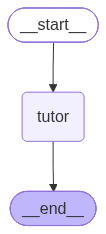

In [52]:
class TutorState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


def tutor_com_perfil(state: TutorState, runtime: Runtime[CursoContext]):
    aluno = runtime.context.aluno.lower()

    perfil = runtime.store.get(("perfil_aluno", aluno), "dados")
    contexto_perfil = ""
    if perfil is not None:
        contexto_perfil = (
            f"O aluno está no módulo {perfil.value['modulo_atual']} "
            f"e já concluiu: {', '.join(perfil.value['modulos_concluidos'])}."
        )

    episodios = list(runtime.store.search(("episodios", aluno)))
    contexto_episodios = "; ".join(ep.value["resumo"] for ep in episodios) or "Nenhuma conversa anterior registrada."

    system_prompt = f"""Você é um tutor do curso de LangGraph.

Contexto do aluno: {contexto_perfil}
Conversas anteriores: {contexto_episodios}

Use esse contexto para personalizar a resposta, sem inventar informações que não foram fornecidas."""

    response = llm.invoke([SystemMessage(content=system_prompt), *state["messages"]])
    return {"messages": [response]}


builder = StateGraph(TutorState, context_schema=CursoContext)
builder.add_node("tutor", tutor_com_perfil)
builder.add_edge(START, "tutor")
builder.add_edge("tutor", END)

grafo_com_perfil = builder.compile(store=store)
display_graph(grafo_com_perfil)


In [53]:
resultado = grafo_com_perfil.invoke(
    {"messages": [HumanMessage(content="Bom dia! Sobre o que a gente já conversou mesmo?")]},
    context=CursoContext(aluno="Renan"),
)
print_last_message(resultado)


Bom dia! Nós já conversamos sobre reducers e como funciona a função `add_messages`. Além disso, você pediu ajuda para montar um roteador de intenção com LLM. Se precisar de mais detalhes sobre algum desses tópicos ou se tiver novas perguntas, estou aqui para ajudar!

## Discussão

- O `store` não substitui o checkpointer — ele resolve um problema diferente: informação que precisa sobreviver a **novas threads**, não apenas a passos dentro da mesma thread.
- Namespaces são a ferramenta de organização do store. Um padrão comum é `(entidade, id_do_usuario)`, como fizemos com `("perfil_aluno", "renan")` e `("episodios", "renan")`.
- Memória tipo **documento** (um registro que é atualizado) e memória **episódica** (uma lista de registros que só cresce) são dois padrões de uso do mesmo store — a diferença está em como você desenha a chave, não em uma API separada.
- Em produção, `SqliteStore` pode ser trocado por `PostgresStore` sem mudar a lógica dos nós.


---

# 6. Juntando tudo: um agente com memória de curto e longo prazo

Agora compilamos um único grafo com **as duas camadas** ao mesmo tempo:

- `checkpointer`: lembra a conversa atual (curto prazo, por `thread_id`).
- `store`: lembra o aluno entre conversas diferentes (longo prazo, por namespace).

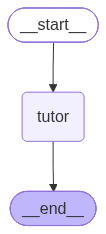

In [54]:
grafo_completo = builder.compile(checkpointer=checkpointer, store=store)
display_graph(grafo_completo)


Simulamos duas conversas de Renan em *threads* diferentes — como se fossem duas sessões de estudo em dias distintos.

In [56]:
config_sessao_1 = {"configurable": {"thread_id": "renan-sessao-1"}}

resultado = grafo_completo.invoke(
    {"messages": [HumanMessage(content="Oi! Pode me lembrar do que já conversamos antes?")]},
    config=config_sessao_1,
    context=CursoContext(aluno="Renan"),
)
print_last_message(resultado)

salvar_episodio("renan", "Retomou o curso e revisou o que já tinha sido conversado.")


Oi! Claro! Nas nossas conversas anteriores, você fez perguntas sobre reducers e a função `add_messages`. Também pediu ajuda para montar um roteador de intenção com LLM. Se precisar de mais informações sobre algum desses tópicos ou tiver novas dúvidas, estou à disposição!

In [57]:
config_sessao_2 = {"configurable": {"thread_id": "renan-sessao-2"}}

resultado = grafo_completo.invoke(
    {"messages": [HumanMessage(content="E aí, em que módulo eu estou mesmo?")]},
    config=config_sessao_2,
    context=CursoContext(aluno="Renan"),
)
print_last_message(resultado)


Você está no módulo A6. Se precisar de ajuda com algum conteúdo específico desse módulo ou tiver dúvidas sobre o que já aprendeu, é só avisar!

Repare: `renan-sessao-1` e `renan-sessao-2` são *threads* completamente diferentes — o checkpointer não compartilha mensagens entre elas. Ainda assim, o assistente conseguiu responder sobre o módulo atual e sobre conversas anteriores, porque essa informação vive no `store`, não no checkpoint da thread.

```text
checkpointer → memória DENTRO de uma conversa
store        → memória ENTRE conversas
```


---

# 7. Exercícios de fixação

## Exercício 1 — Novo campo no `Context`

Adicione um campo `nivel` (`"iniciante"`, `"intermediario"` ou `"avancado"`) ao `CursoContext`.

Modifique `tutor_com_perfil` para ajustar o tom da resposta de acordo com o nível informado.

## Exercício 2 — `thread_id` automático

Nos exemplos desta aula, escolhemos o `thread_id` manualmente. Escreva uma função `nova_sessao(aluno: str) -> dict` que gera um `thread_id` único (dica: `uuid.uuid4()`) e devolve o `config` pronto para uso.

## Exercício 3 — Atualizando o perfil dentro de um nó

Hoje, `salvar_perfil_aluno` é chamada manualmente, fora do grafo. Crie um nó `atualizar_progresso` que, ao final da conversa, atualiza `modulo_atual` no store com base no que foi discutido (pode ser uma regra simples, sem precisar de LLM).

## Exercício 4 — Limitando o histórico de episódios

Modifique o trecho que monta `contexto_episodios` em `tutor_com_perfil` para usar apenas os **3 episódios mais recentes**, em vez de todos.

## Exercício 5 — Comparando memórias

Crie duas *threads* para a Ana (`ana-sessao-1` e `ana-sessao-2`) e mostre, com `print`, que:

1. mensagens da sessão 1 não aparecem na sessão 2 (checkpointer isolado por thread);
2. o perfil e os episódios da Ana aparecem nas duas sessões (store compartilhado entre threads).

## Exercício 6 — Checkpointer vs. Store, na prática

Sem rodar código, responda: se você guardasse a preferência de idioma do aluno **apenas no checkpoint** (dentro de `messages`, por exemplo), o que aconteceria na segunda vez que esse aluno abrisse uma conversa nova? Explique com suas palavras a diferença prática entre as duas camadas de memória.

---

# 8. Resumo da aula

Neste notebook, vimos como dar memória de verdade a um agente em LangGraph. Os pontos principais foram:

- o estado do grafo, sozinho, só existe durante uma chamada — não é memória;
- `RunnableConfig` permite passar metadados de execução (como `thread_id`) para dentro dos nós;
- `Runtime`/`context_schema` é a evolução tipada do `RunnableConfig` para dados de contexto imutáveis;
- `checkpointer` (ex.: `SqliteSaver`) implementa memória de **curto prazo**: o estado inteiro é salvo a cada passo, associado a um `thread_id`;
- `store` (ex.: `SqliteStore`) implementa memória de **longo prazo**: informação organizada em namespaces, acessível de qualquer thread;
- dois padrões comuns de uso do store são memória tipo **documento** (um registro atualizado) e memória **episódica** (uma lista de registros que cresce);
- os dois mecanismos são complementares e podem ser usados juntos no mesmo grafo.


## 8.1 Checklist de compreensão

Antes de seguir para os próximos tópicos, você deve conseguir responder:

1. Qual é a diferença entre `config["configurable"]` e `runtime.context`?
2. Por que `thread_id` continua vivendo em `config`, mesmo depois de adotar `Runtime`/`Context`?
3. O que exatamente um checkpointer salva a cada passo do grafo?
4. Por que duas *threads* diferentes não compartilham checkpoints?
5. O que é um namespace no `store`, e como ele normalmente é estruturado?
6. Qual é a diferença prática entre memória tipo documento e memória episódica?


## 8.2 Próximos passos

Agora que o agente tem memória de curto e de longo prazo, os próximos passos naturais são:

- combinar memória com ferramentas (Notebook 4), para que o agente decida **quando** consultar ou atualizar o store;
- usar `search` com busca semântica (embeddings) em vez de listar tudo de um namespace;
- avaliar critérios de quando resumir/podar o histórico de uma thread muito longa, para não estourar o contexto do modelo.


# 9. Referências

- LangGraph — Persistence (checkpointer): https://docs.langchain.com/oss/python/langgraph/persistence
- LangGraph — Memory (store): https://docs.langchain.com/oss/python/langgraph/memory
- LangGraph — Runtime e Context: https://docs.langchain.com/oss/python/langgraph/context
- LangGraph — Graph API: https://docs.langchain.com/oss/python/langgraph/graph-api
- Referência `SqliteSaver`: https://reference.langchain.com/python/langgraph.checkpoint.sqlite/SqliteSaver
- Referência `SqliteStore` / Store System: https://reference.langchain.com/python/langgraph/store
